In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
df = pd.read_csv(r"C:\Users\MARSHED\Downloads\D3\Finalized\D-Balance\pi_2025_09_06_20_55_00\220_ca_oa.csv", 
                 header=None, names=['ca', 'oa'])
print(df)


# df1=pd.read_csv(r'C:\Users\MARSHED\Downloads\D3\D-Balance\pi_2025_07_27_18_31_36\254_calculated.csv')
# print(df1)
# print(df)
df['ca/oa']= df['ca']/df['oa']

         ca    oa
0      1312  3982
1      1283  3965
2      1265  3997
3      1280  4018
4      1297  3998
...     ...   ...
11995  1237  3983
11996  1270  3973
11997  1253  3955
11998  1252  4029
11999  1263  3997

[12000 rows x 2 columns]


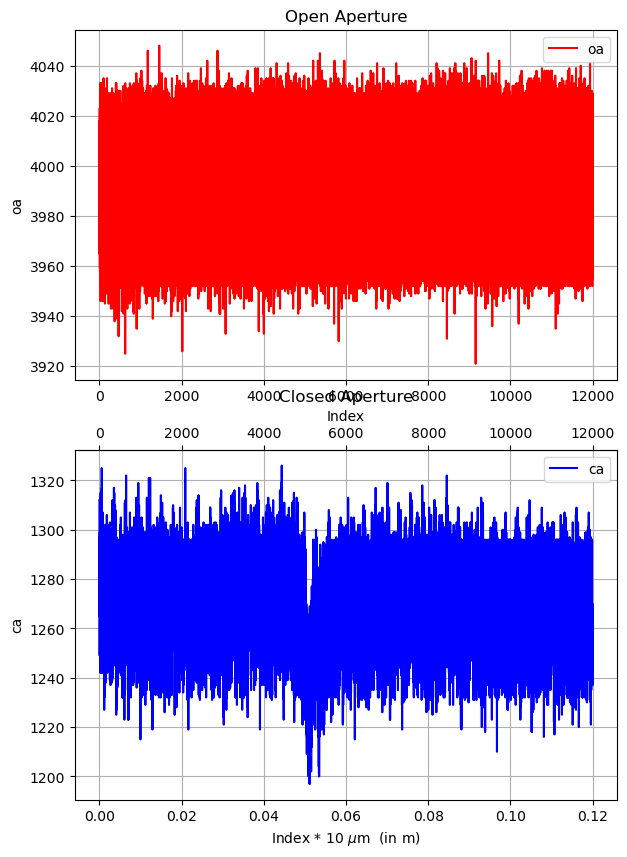

In [4]:
import matplotlib.pyplot as plt

# Create 2 subplots stacked vertically
fig, axs = plt.subplots(2, 1, figsize=(7, 10))

# 1. ca plot
axs[1].plot(df.index*.00001, df['ca'], color='blue', label='ca')
axs[1].set_xlabel('Index * 10 $\mu$m  (in m)')

def meter_to_index(x):
    return x / 1e-5

def index_to_meter(x):
    return x * 1e-5

secax = axs[1].secondary_xaxis('top', functions=(meter_to_index, index_to_meter))
secax.set_xlabel('Index')
axs[1].set_ylabel('ca')
axs[1].set_title('Closed Aperture')
axs[1].legend()
axs[1].grid(True)

# 2. oa plot
axs[0].plot(df.index, df['oa'], color='red', label='oa')
axs[0].set_ylabel('oa')
axs[0].set_title('Open Aperture')
axs[0].legend()
axs[0].grid(True)


In [5]:
# Lock the first 300 and last 300 rows for mean calculation on 'ca' and 'oa' columns
mean_ca = pd.concat([df['ca'].head(300), df['ca'].tail(300)]).mean()
mean_oa = pd.concat([df['oa'].head(300), df['oa'].tail(300)]).mean()
mean_ca_oa = pd.concat([df['ca/oa'].head(10), df['ca/oa'].tail(10)]).mean()

# Normalize the 'ca' and 'oa' columns separately
df['normalized_ca'] = df['ca'] / mean_ca
df['normalized_oa'] = df['oa'] / mean_oa
df['normalized_ca/oa'] = df['normalized_ca'] / df['normalized_oa']

# Remove zero points from the normalized data
df_nonzero = df[(df['normalized_ca'] != 0) & (df['normalized_oa'] != 0)]

# Optionally display the result
print(df_nonzero.head())

     ca    oa     ca/oa  normalized_ca  normalized_oa  normalized_ca/oa
0  1312  3982  0.329483       1.031649       0.998257          1.033451
1  1283  3965  0.323581       1.008846       0.993995          1.014941
2  1265  3997  0.316487       0.994692       1.002017          0.992690
3  1280  4018  0.318566       1.006487       1.007282          0.999211
4  1297  3998  0.324412       1.019855       1.002268          1.017547


In [42]:
df

,ca,oa,ca/oa,normalized_ca,normalized_oa,normalized_ca/oa
0,1423,3905,0.364405,0.993240,0.984322,1.009060
1,1447,3984,0.363203,1.009992,1.004236,1.005732
2,1439,3965,0.362926,1.004408,0.999446,1.004964
3,1433,3942,0.363521,1.000220,0.993649,1.006613
4,1422,3917,0.363033,0.992542,0.987347,1.005261
...,...,...,...,...,...,...
11995,1430,3952,0.361842,0.998126,0.996169,1.001964
11996,1425,3965,0.359395,0.994636,0.999446,0.995187
11997,1438,4016,0.358068,1.003710,1.012302,0.991513
11998,1439,3998,0.359930,1.004408,1.007765,0.996669


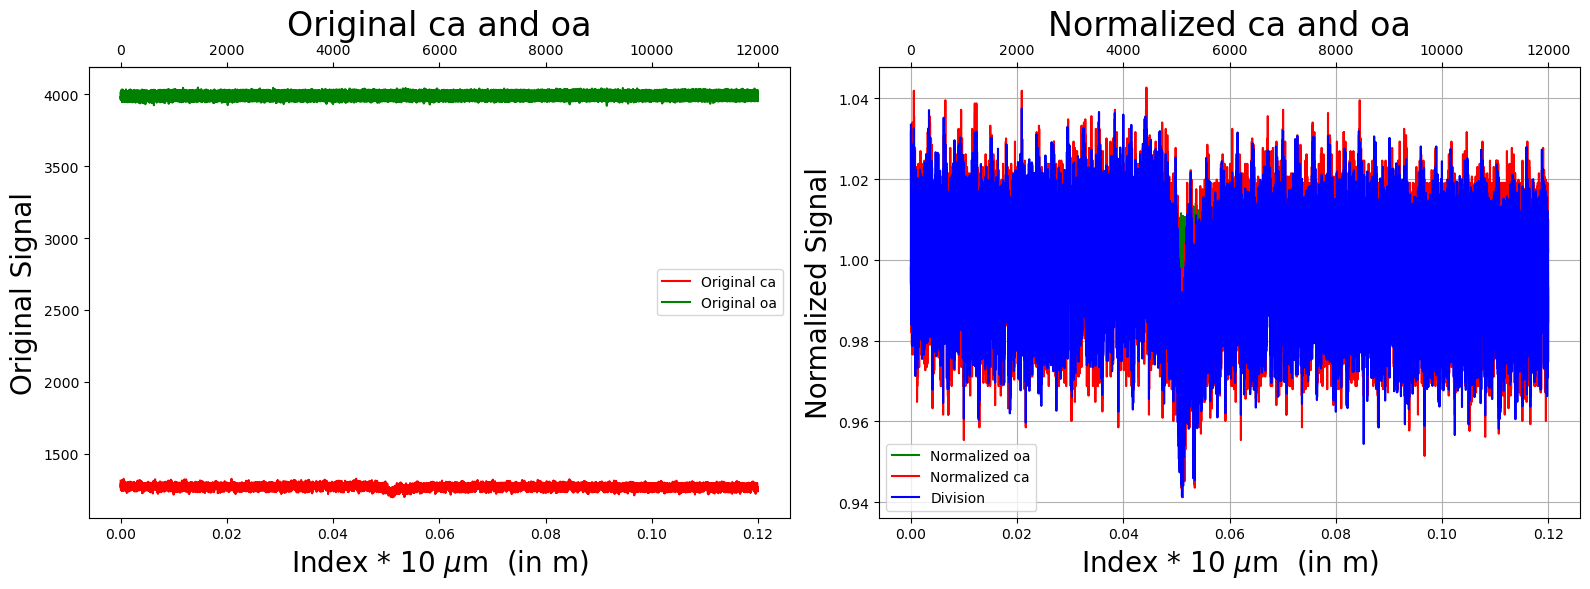

In [6]:
# --- Plotting ---
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharex=True)


# plt.rcParams.update({
#     'axes.titlesize': 20,
#     'axes.labelsize': 20,
#     'xtick.labelsize': 20,
#     'ytick.labelsize': 20,
#     'legend.fontsize': 20
# })

# Plot original ca and oa
axs[0].plot(df.index*.00001, df['ca'], label='Original ca', color='red', alpha=1)
axs[0].plot(df.index*.00001, df['oa'], label='Original oa', color='green', alpha=1)
secax = axs[0].secondary_xaxis('top', functions=(meter_to_index, index_to_meter))
#secax.set_xlabel('Index', fontsize=20)
axs[0].set_xlabel('Index * 10 $\mu$m  (in m)', fontsize=20 )
axs[0].set_ylabel('Original Signal', fontsize=20)
axs[0].legend()
axs[0].set_title('Original ca and oa', fontsize=24)
plt.grid('True')
# Plot normalized ca and oa

axs[1].plot(df.index*.00001, df['normalized_oa'], label='Normalized oa', color='green')
axs[1].plot(df.index*.00001, df['normalized_ca'], label='Normalized ca', color='red')
axs[1].plot(df.index*.00001, df['normalized_ca/oa'], label='Division', color='blue')
secax = axs[1].secondary_xaxis('top', functions=(meter_to_index, index_to_meter))
#secax.set_xlabel('Index', fontsize=20)
axs[1].set_ylabel('Normalized Signal', fontsize=20)
axs[1].set_xlabel('Index * 10 $\mu$m  (in m)', fontsize=20 )
axs[1].legend()
axs[1].set_title('Normalized ca and oa', fontsize=24)
plt.grid('True')

plt.tight_layout()
plt.show()

In [7]:
def reduce_data(df, group_size, y_cols):
    """
    Reduce data resolution by grouping consecutive rows and computing
    mean & std for the given y-columns.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame
    group_size : int
        Number of consecutive rows per group
    y_cols : list of str
        Columns for which to calculate mean and std

    Returns
    -------
    pd.DataFrame
        Reduced DataFrame with aggregated statistics
    """
    grouped = df.copy()
    grouped['group'] = grouped.index // group_size

    # Build aggregation dictionary
    agg_dict = {col: ['mean', 'std'] for col in y_cols}

    reduced_df = grouped.groupby('group').agg(agg_dict).reset_index(drop=True)

    # Flatten MultiIndex column names
    reduced_df.columns = [f'{col}_{stat}' for col in y_cols for stat in ['mean', 'std']]

    return reduced_df


In [46]:
reduced_df = reduce_data(
    df_nonzero,
    group_size=10,
    y_cols=['normalized_ca', 'normalized_oa', 'normalized_ca/oa']
)


In [47]:
reduced_df

,normalized_ca_mean,normalized_ca_std,normalized_oa_mean,normalized_oa_std,normalized_ca/oa_mean,normalized_ca/oa_std
0,0.997149,0.006549,0.993296,0.007131,1.003891,0.004420
1,1.000499,0.006888,0.995741,0.007328,1.004786,0.003159
2,0.997847,0.006566,0.995035,0.005861,1.002831,0.004502
3,0.998545,0.007497,0.993296,0.005422,1.005279,0.003874
4,0.999173,0.006271,0.993220,0.006787,1.006011,0.005594
...,...,...,...,...,...,...
1195,1.001337,0.007562,1.003303,0.006225,0.998039,0.004093
1196,1.000499,0.007210,1.003227,0.006287,0.997286,0.004895
1197,1.002733,0.007329,1.004462,0.006002,0.998274,0.003059
1198,1.002663,0.005586,1.004084,0.006410,0.998600,0.004988


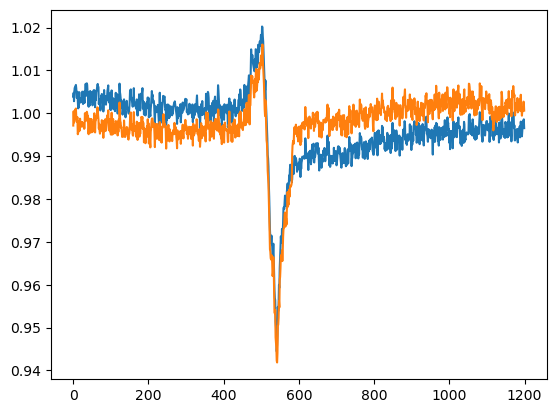

In [48]:
plt.plot(reduced_df['normalized_ca/oa_mean'])
plt.plot(reduced_df['normalized_ca_mean'])

In [49]:
# Step 1: Slice the range from index 4000 to 7000
subset = reduced_df['normalized_ca_mean'].iloc[400:700]  # Include index 7000
#subset1 = df['normalized_ca/oa'].iloc[4000:6000]
# subset2 = df['normalized_oa'].iloc[4000:6000]
# Step 2: Find min and max values and their positions in the full DataFrame
min_val = subset.min()
max_val = subset.max()
min_pos = subset.idxmin()
max_pos = subset.idxmax()

# Step 3: Sort the indices so we can slice correctly
start_idx = min(min_pos, max_pos)
end_idx = max(min_pos, max_pos)

# Step 4: Extract the values in between min and max index
between_values = reduced_df.loc[start_idx:end_idx, 'normalized_ca_mean']
# Create a new DataFrame using the index as x, and values as normalized_ca
df_between = pd.DataFrame({
    'x': between_values.index,
    'normalized_ca/oa': between_values.values
})
print(df_between)

      x  normalized_ca/oa
0   503          1.016064
1   504          1.012714
2   505          1.010899
3   506          1.008666
4   507          1.006921
5   508          1.003849
6   509          1.000988
7   510          0.999382
8   511          1.003012
9   512          0.999661
10  513          0.996311
11  514          0.993729
12  515          0.992961
13  516          0.990657
14  517          0.986609
15  518          0.984864
16  519          0.983538
17  520          0.980118
18  521          0.976837
19  522          0.972510
20  523          0.968252
21  524          0.967763
22  525          0.966228
23  526          0.965879
24  527          0.966018
25  528          0.966856
26  529          0.964971
27  530          0.962040
28  531          0.962808
29  532          0.966437
30  533          0.963855
31  534          0.958480
32  535          0.953664
33  536          0.953315
34  537          0.954083
35  538          0.947731
36  539          0.946544
37  540     

In [50]:
# Number of rows to drop from start and end
n = len(df_between)
drop_count = int(0.1 * n)

# Slice the DataFrame to keep middle 70%
cropped_df = df_between.iloc[drop_count : n - drop_count]

# 4. Extract x and normalized_ca arrays for regression
mid_data_x = cropped_df['x'].values
mid_data_y = cropped_df['normalized_ca/oa'].values
coefficients = np.polyfit(mid_data_x, mid_data_y, 1) # 1 indicates degree of polynomial

slope = coefficients[0]
intercept = coefficients[1]
x_pred = (1/slope) - (intercept/slope)
print(x_pred)

# 1. Extract original index as x
x = reduced_df.index.to_numpy()

# 2. Define your transform function
def transform_x(x, x_pred):
    return (x - x_pred) * 1e-4 

# 3. Compute transformed x
x_transformed = transform_x(x, x_pred)

# 4. Add to DataFrame as a new column
reduced_df['x_position'] = x_transformed

509.87194157114936


In [51]:
reduced_df

,normalized_ca_mean,normalized_ca_std,normalized_oa_mean,normalized_oa_std,normalized_ca/oa_mean,normalized_ca/oa_std,x_position
0,0.997149,0.006549,0.993296,0.007131,1.003891,0.004420,-0.050987
1,1.000499,0.006888,0.995741,0.007328,1.004786,0.003159,-0.050887
2,0.997847,0.006566,0.995035,0.005861,1.002831,0.004502,-0.050787
3,0.998545,0.007497,0.993296,0.005422,1.005279,0.003874,-0.050687
4,0.999173,0.006271,0.993220,0.006787,1.006011,0.005594,-0.050587
...,...,...,...,...,...,...,...
1195,1.001337,0.007562,1.003303,0.006225,0.998039,0.004093,0.068513
1196,1.000499,0.007210,1.003227,0.006287,0.997286,0.004895,0.068613
1197,1.002733,0.007329,1.004462,0.006002,0.998274,0.003059,0.068713
1198,1.002663,0.005586,1.004084,0.006410,0.998600,0.004988,0.068813


In [52]:
filtered_df = reduced_df[(reduced_df['x_position'] > -0.03) & (reduced_df['x_position'] < 0.03)]
filtered_df

,normalized_ca_mean,normalized_ca_std,normalized_oa_mean,normalized_oa_std,normalized_ca/oa_mean,normalized_ca/oa_std,x_position
210,0.998824,0.005756,0.994909,0.006177,1.003945,0.004114,-0.029987
211,0.998684,0.005763,0.994405,0.005696,1.004308,0.003389,-0.029887
212,0.996800,0.004129,0.994329,0.006741,1.002511,0.005435,-0.029787
213,0.997009,0.005035,0.994002,0.006761,1.003042,0.003963,-0.029687
214,0.997777,0.005833,0.995212,0.006431,1.002586,0.003288,-0.029587
...,...,...,...,...,...,...,...
805,0.999522,0.006703,1.007386,0.006080,0.992201,0.004976,0.029513
806,0.998405,0.006753,1.006555,0.007015,0.991914,0.004455,0.029613
807,1.000639,0.005025,1.008470,0.006490,0.992249,0.004204,0.029713
808,1.003431,0.005739,1.007790,0.006417,0.995684,0.003463,0.029813


In [53]:
lmda = 660e-9 #wave length of laser in meter (red)
#F = #focal length of the lens
#D = #beam diameter
#w0 = ((2*lmda*F)/((np.pi)*D)) #formula for beam waist.
w0 = 2.1e-5 #beam waist for the above light in meters
z0 = (np.pi)*(w0*w0)/lmda # Rayleigh range

In [54]:
from sklearn.metrics import r2_score
from scipy import stats

def compute_fit_stats(Yax, Yax2, sigma=None):
    """
    Compute fit statistics between observed (Yax) and predicted (Yax2) values.

    Args:
        Yax       : array-like, observed values
        Yax2      : array-like, predicted/fitted values
        sigma     : array-like or None, uncertainties for each point (default: 1)
        n_params  : int, number of fitted parameters (for reduced chi-squared)

    Returns:
        dict with:
            - R_sq        : Coefficient of determination
            - percent     : R_sq in percentage
            - Y_diff      : Absolute differences
            - RMSE        : Root Mean Squared Error
            - MAE         : Mean Absolute Error
            - MAPE        : Mean Absolute Percentage Error (if no zero values in Yax)
            - chi2        : Chi-squared
            - chi2_red    : Reduced chi-squared
    """
    Yax = np.array(Yax, dtype=float)
    Yax2 = np.array(Yax2, dtype=float)

    if Yax.shape != Yax2.shape:
        raise ValueError("Input arrays must have the same shape.")

    # Differences
    diff = Yax - Yax2
    Y_diff = np.abs(diff)
    
    # Variance for R^2 (Regression style)
    total_variance = np.sum((Yax - np.mean(Yax)) ** 2)
    residual_variance = np.sum(diff ** 2)
    
    # R-squared
    if total_variance == 0:
        R_sq = 1.0 if np.allclose(Yax, Yax2) else 0.0
    else:
        R_sq = 1 - (residual_variance / total_variance)
    percent = R_sq * 100

###############################
# #   R^2 (Pearson style)
#     r_value, _ = stats.pearsonr(Yax, Yax2)
#     R_sq = r_value ** 2
#     percent = R_sq * 100
###############################
#     R_sq = r2_score(Yax, Yax2)
#     percent = R_sq * 100

    # Error metrics
    RMSE = np.sqrt(np.mean(diff ** 2))
    MAE = np.mean(Y_diff)
    MAPE = np.mean(np.abs(diff / Yax)) * 100 if np.all(Yax != 0) else np.nan

    # Chi-squared
    if sigma is None:
        sigma = np.ones_like(Yax)
    else:
        sigma = np.array(sigma, dtype=float)
        if sigma.shape != Yax.shape:
            raise ValueError("sigma must have the same shape as Yax")
    
    chi_sq = np.sum((diff / sigma) ** 2)

    return {
        'Y_diff': Y_diff,
        'R_sq': percent,
        'RMSE': RMSE,
        'MAE': MAE,
        'MAPE (%)': MAPE,
        'chi_sq': chi_sq
    }

Y_diff: [3.76009423e-03 4.12179666e-03 2.32235558e-03 2.85177777e-03
 2.39386229e-03 1.99866840e-03 3.86880833e-04 2.94563525e-03
 1.46143397e-03 8.03683282e-04 4.64756994e-05 1.16419306e-03
 1.03896191e-04 9.10601235e-04 1.11366393e-04 1.76243543e-03
 9.91010395e-05 1.24149696e-03 2.89800282e-03 9.49430083e-04
 4.58169430e-03 1.00868470e-04 7.71528570e-05 1.12549084e-03
 2.20931506e-03 2.36473727e-03 5.93351529e-04 1.50394515e-03
 2.50909280e-03 3.82575652e-03 2.88087635e-03 3.22075392e-03
 3.67566687e-03 3.63308087e-03 1.19872507e-03 5.15311698e-04
 6.38469468e-04 2.94995198e-03 6.59127366e-05 1.87481738e-03
 1.77887889e-03 2.92213578e-04 3.89158690e-04 1.72599143e-03
 1.40967358e-03 4.87814111e-04 1.22697416e-03 9.79850846e-04
 5.17665760e-04 1.34039024e-03 7.76082170e-04 6.69687783e-04
 5.14721812e-04 7.79136736e-04 9.81958008e-04 3.63672483e-04
 1.35598030e-03 1.46545845e-03 2.00697439e-03 2.02111339e-03
 2.44263924e-03 1.77415378e-03 1.19419343e-03 3.84845939e-04
 1.20150849e-04 

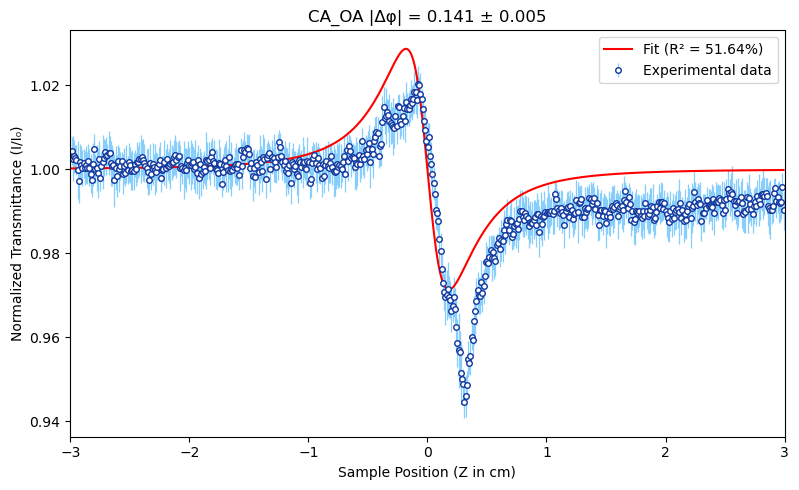

In [55]:
# Extract arrays from df
Xax = filtered_df['x_position'].to_numpy()              # in meters
Xcm = Xax * 100                       # convert to centimeters
x = Xax / z0                         # normalized Z
Yax = filtered_df['normalized_ca/oa_mean'].to_numpy()

# defining the curve fitting function as "zscan"
def zscan(x,phi):
   T = 1 +(((4*x)/(((1 + x**2) * (9 + x**2))))*phi) #closed aparture Z-scan formula
   return T

# Using the Scipy curve fit module
popt, pcov = curve_fit(zscan, x, Yax) # fitting the "zscan function", finding the optimized parameter 'popt' and its coverience 'pcov'
Yax2 = zscan(x, *popt) # getting predicted values from the "zscan" function and naming them as "Yax3"

delphi = popt[0]
delphi_err = np.sqrt(pcov[0][0])

fit_stats = compute_fit_stats(Yax, Yax2, sigma=filtered_df['normalized_ca/oa_std'])
for k, v in fit_stats.items():
    print(f"{k}: {v}")
    
R_sq=fit_stats['R_sq']
    
# Plotting
plt.figure(figsize=(1.618 * 5, 5))
plt.title(rf"CA_OA |Δφ| = {abs(delphi):.3f} ± {delphi_err:.3f}")
plt.ylabel(r"Normalized Transmittance (I/I₀)", fontsize=10)
plt.xlabel("Sample Position (Z in cm)", fontsize=10)
plt.xlim(-3, 3)

plt.errorbar(Xcm, Yax, yerr=filtered_df['normalized_ca/oa_std'], fmt='.', color='#0C359E', ecolor='lightskyblue', elinewidth=0.9, markersize=8, mfc='w', label='Experimental data')
plt.plot(
    Xcm, Yax2, '-', color='red',
    label=f'Fit (R² = {R_sq:.2f}%)'
)
plt.legend()
plt.tight_layout()
plt.show()


Y_diff: [2.24326760e-03 1.33635137e-04 2.68373683e-03 1.73178401e-03
 1.08263331e-03 3.34029880e-04 1.46029823e-03 4.08616967e-04
 1.22388474e-03 4.33260661e-04 2.09287071e-03 4.38175049e-04
 8.93792117e-04 2.54165644e-03 1.31425966e-03 4.95501490e-03
 2.81186286e-04 4.67802232e-04 7.26205064e-04 2.61710717e-03
 1.94820736e-03 1.01840226e-03 1.93757801e-03 2.95130692e-03
 4.27654475e-03 3.34030635e-03 3.68879037e-03 4.15230847e-03
 4.11834418e-03 1.69268169e-03 1.01791295e-03 1.14969416e-03
 2.42999375e-03 5.94415014e-04 1.33762470e-03 2.32460193e-03
 2.62208599e-04 9.52202615e-04 2.29764068e-03 8.29286415e-04
 1.07679573e-03 6.29290352e-04 1.58612580e-03 9.73108666e-05
 1.96397408e-03 1.40834666e-03 2.87138993e-05 1.34918194e-04
 1.20815130e-04 1.64890576e-03 3.11995102e-04 2.04028223e-03
 2.15844510e-03 2.70863694e-03 2.73147095e-03 3.16168387e-03
 2.50192114e-03 1.93068502e-03 1.13007260e-03 6.33806338e-04
 2.32107877e-04 2.06822094e-03 1.83670770e-03 7.62530596e-04
 1.59054567e-03 

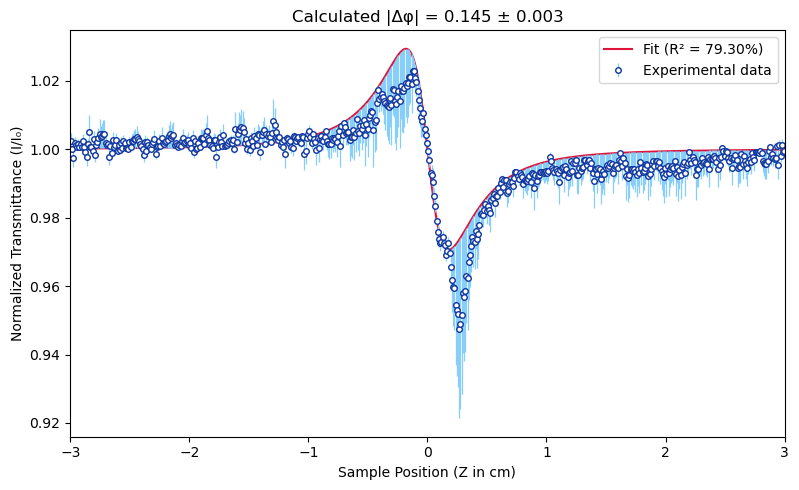

In [56]:
# Extract arrays from df
Xax = df1['x'].to_numpy()              # in meters
Xcm = Xax * 100                       # convert to centimeters
x = Xax / z0                         # normalized Z
Yax = df1['I/I0'].to_numpy()

# defining the curve fitting function as "zscan"
def zscan(x,phi):
   T = 1 +(((4*x)/(((1 + x**2) * (9 + x**2))))*phi) #closed aparture Z-scan formula
   return T

# Using the Scipy curve fit module
popt, pcov = curve_fit(zscan, x, Yax) # fitting the "zscan function", finding the optimized parameter 'popt' and its coverience 'pcov'
Yax2 = zscan(x, *popt) # getting predicted values from the "zscan" function and naming them as "Yax3"

delphi = popt[0]
delphi_err = np.sqrt(pcov[0][0])

fit_stats = compute_fit_stats(Yax, Yax2)
for k, v in fit_stats.items():
    print(f"{k}: {v}")
    
Y_diff = fit_stats['Y_diff']
R_sq=fit_stats['R_sq']
    
# Plotting
plt.figure(figsize=(1.618 * 5, 5))
plt.title(rf"Calculated |Δφ| = {abs(delphi):.3f} ± {delphi_err:.3f}")
plt.ylabel(r"Normalized Transmittance (I/I₀)", fontsize=10)
plt.xlabel("Sample Position (Z in cm)", fontsize=10)
plt.xlim(-3, 3)
plt.plot(
    Xcm, Yax2, '-', color='crimson',
    label=f'Fit (R² = {R_sq:.2f}%)'
)
plt.errorbar(Xcm, Yax, yerr=Y_diff, fmt='.', color='#0C359E', ecolor='lightskyblue', elinewidth=0.9, markersize=8, mfc='w', label='Experimental data')

plt.legend()
plt.tight_layout()
plt.show()

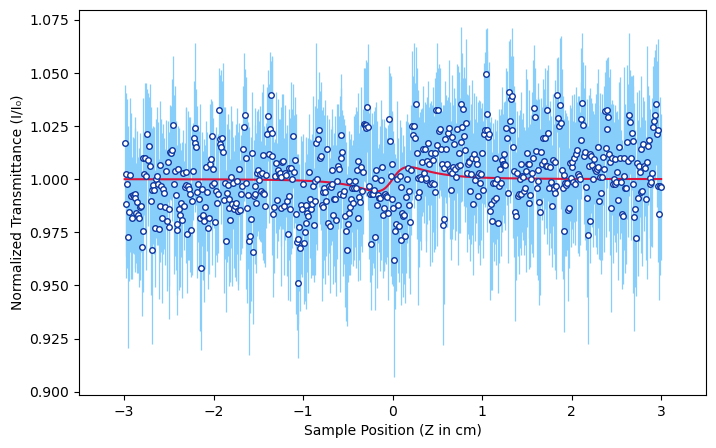

In [93]:
# Extract arrays from df
Xax = filtered_df['x_position'].to_numpy()              # in meters
Xcm = Xax * 100                       # convert to centimeters
x = Xax / z0                         # normalized Z
Yax = filtered_df['normalized_ca_mean'].to_numpy()

# defining the curve fitting function as "zscan"
def zscan(x,phi):
   T = 1 +(((4*x)/(((1 + x**2) * (9 + x**2))))*phi) #closed aparture Z-scan formula
   return T

# Using the Scipy curve fit module
popt, pcov = curve_fit(zscan, x, Yax) # fitting the "zscan function", finding the optimized parameter 'popt' and its coverience 'pcov'
Yax2 = zscan(x, *popt) # getting predicted values from the "zscan" function and naming them as "Yax3"

delphi = popt[0]
delphi_err = np.sqrt(pcov[0][0])


# Plotting
plt.figure(figsize=(1.618 * 5, 5))
#plt.title(r'Closed Aperture Z-scan profile at {:.2f} mW'.format(pwr_mW), fontsize=12)
plt.ylabel(r"Normalized Transmittance (I/I₀)", fontsize=10)
plt.xlabel("Sample Position (Z in cm)", fontsize=10)
plt.xlim(-3.5, 3.5)

plt.errorbar(Xcm, Yax, yerr=filtered_df['normalized_ca_std'], fmt='.', color='#0C359E', ecolor='lightskyblue', elinewidth=0.9, markersize=8, mfc='w', label='Experimental data')
plt.plot(Xcm, Yax2, '-', color='crimson')


In [94]:
delphi

0.02821939512153282